In [2]:
# library importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import h3
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report,roc_curve, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')


/Users/neha/Projects/Spatio-Temporal Traffic Risk Engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# dataset loading
data = pd.read_csv("data/US_Accidents.csv")


In [4]:
data.shape

(7728394, 46)

7.7 million rows and 46 columns

In [5]:
data.columns.tolist()

['ID',
 'Source',
 'Severity',
 'Start_Time',
 'End_Time',
 'Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Direction',
 'Wind_Speed(mph)',
 'Precipitation(in)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

In [6]:
data.isnull().sum()

ID                             0
Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3402762
End_Lng                  3402762
Distance(mi)                   0
Description                    5
Street                     10869
City                         253
County                         0
State                          0
Zipcode                     1915
Country                        0
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Amenity                        0
Bump      

In [7]:
# Restricting  the analysis to California only
data_california=data[data["State"]=="CA"].copy()
del data


In [8]:
data_california.shape

(1741433, 46)

1.74 million rows and 46 columns

In [9]:
data_california.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  637331
End_Lng                  637331
Distance(mi)                  0
Description                   3
Street                     2442
City                         11
County                        0
State                         0
Zipcode                     597
Country                       0
Timezone                    597
Airport_Code               2116
Weather_Timestamp         32805
Temperature(F)            45969
Wind_Chill(F)            510965
Humidity(%)               48341
Pressure(in)              37126
Visibility(mi)            40125
Wind_Direction            46189
Wind_Speed(mph)          162891
Precipitation(in)        566204
Weather_Condition         39778
Amenity                       0
Bump                          0
Crossing

Data Cleaning

let's drop columns first :
droping High-Missing Columns :
 Wind_Chill(F) because of  Multicollinearity  (Temperature(F) and Wind_Speed(mph) )
 Precipitation(in)

We have Start_Lat and Start_Lng with 0 missing values; for point-of-accident risk, the start coordinates are the most important.
 So we can drop End_Lat and End_Lng

End_Lat, End_Lng, Distance(mi), Description -Result, Not Cause-These describe the aftermath of the accident.
 Using them to predict the accident is Target Leakage.

ID, Street, Zipcode, Airport_Code -High Cardinality-Too many unique values.
The model will try to memorize specific streets instead of learning general patterns.

City, County, Country, Timezone-Redundant Location
We are using H3 Hexagons and Start_Lat/Lng. These are much more precise than a City name.

Weather_Timestamp, Wind_Direction, Pressure(in)
Redundant Weather-Temperature and Humidity capture 90% of the weather signal. Pressure changes are too subtle for accident prediction.

Source, Turning_Loop
 Constant/Useless-If a column has only one value (like Turning_Loop often does), the model learns nothing.

In [10]:
data_california.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [11]:
# Keep only the columns needed for time, location, weather, and road-context feature engineering
essential_features=[
    "Start_Time",'Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)','Weather_Condition','Sunrise_Sunset','Crossing', 'Junction', 'Stop', 'Traffic_Signal', 'Station'

]


In [12]:
# Droping  rows that cannot support the downstream feature pipeline or dashboard scenario scoring
data_california=data_california[essential_features].dropna()


In [13]:
data_california.shape

(1560870, 14)

In [14]:
# Parsing timestamps once here so temporal sorting and cyclical hour features behave consistently
data_california['Start_Time'] = pd.to_datetime(data_california['Start_Time'], errors='coerce')


In [15]:
data_california["Start_Time"]


728       2016-06-21 10:34:40
729       2016-06-21 10:30:16
730       2016-06-21 10:49:14
731       2016-06-21 10:41:42
732       2016-06-21 10:16:26
                  ...        
7728389   2019-08-23 18:03:25
7728390   2019-08-23 19:11:30
7728391   2019-08-23 19:00:21
7728392   2019-08-23 19:00:21
7728393   2019-08-23 18:52:06
Name: Start_Time, Length: 1560870, dtype: datetime64[us]

In [16]:
# Creating  the positive class
df_pos = data_california.copy()
df_pos['target'] = 1

# Creating a synthetic 'safe' class by permuting time and location while preserving weather/context columns
# This forces the model to learn more than raw accident density alone
df_neg = data_california.copy()
df_neg['target'] = 0

# Permutation Sampling: Shuffle Time and Space to create 'Safe' scenarios
df_neg['Start_Time'] = np.random.permutation(df_neg['Start_Time'].values)
df_neg['Start_Lat'] = np.random.permutation(df_neg['Start_Lat'].values)
df_neg['Start_Lng'] = np.random.permutation(df_neg['Start_Lng'].values)

# Combine positives and synthetic negatives into one modeling table
df_modeling = pd.concat([df_pos, df_neg], axis=0).reset_index(drop=True)


In [17]:

# TEMPORAL SPLIT
# Sort chronologically so the model trains on the past and validates on future-like data
df_modeling = df_modeling.sort_values('Start_Time')

split_idx = int(len(df_modeling) * 0.8)
train_df = df_modeling.iloc[:split_idx].copy()
test_df = df_modeling.iloc[split_idx:].copy()

print(f"Training on: {len(train_df)} rows (Past)")
print(f"Testing on: {len(test_df)} rows (Future)")



Training on: 2497392 rows (Past)
Testing on: 624348 rows (Future)


In [18]:
# SPATIAL & TEMPORAL ENGINEERING

# 1. Convert each accident to an H3 resolution-7 hex cell so local neighborhood effects become measurable
train_df['h3_res7'] = [h3.latlng_to_cell(lat, lng, 7) for lat, lng in zip(train_df['Start_Lat'], train_df['Start_Lng'])]
test_df['h3_res7'] = [h3.latlng_to_cell(lat, lng, 7) for lat, lng in zip(test_df['Start_Lat'], test_df['Start_Lng'])]

# 2. LEAK-PROOF NEIGHBOR RISK
# Build spatial risk memory from the training accidents only so future rows do not leak signal backwards
train_hex_risk = train_df[train_df['target'] == 1]['h3_res7'].value_counts().to_dict()

def get_spatial_risk_safe(hex_id):
    neighbors = h3.grid_disk(hex_id, 1)
    return sum(train_hex_risk.get(n, 0) for n in neighbors)

train_df['neighbor_risk'] = train_df['h3_res7'].apply(get_spatial_risk_safe)
test_df['neighbor_risk'] = test_df['h3_res7'].apply(get_spatial_risk_safe)



In [ ]:
# Log transform the spatial counts so extremely dense cells do not dominate the scale outright
train_df['neighbor_risk'] = np.log1p(train_df['neighbor_risk'])
test_df['neighbor_risk'] = np.log1p(test_df['neighbor_risk'])

# 3. Time & Interactions
# Encode hour cyclically and create a simple humidity-time interaction feature
for df in [train_df, test_df]:
    df['hour'] = df['Start_Time'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['wet_rush_hour'] = (df['Humidity(%)'] / 100) * df['hour_sin']


In [19]:

# PREPARATION & TRAINING
# Remove identifiers and raw columns that have already been transformed into model features
drop_cols = ['target', 'Start_Lat', 'Start_Lng', 'Start_Time', 'h3_res7', 'hour']
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target']
X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target']



In [20]:
# Cast categorical predictors explicitly so LightGBM handles them natively
cat_cols = ['Weather_Condition', 'Sunrise_Sunset']
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Train the binary LightGBM classifier with AUC as the primary validation target
model = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=1000,
    scale_pos_weight=1.5, # Balances Precision/Recall
    importance_type='gain',
    random_state=42,
    n_jobs=-1,
    force_row_wise=True
)



In [21]:
# Early stopping keeps the model from overtraining once validation performance plateaus
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

# EVALUATION
# Score the future holdout split to estimate how the model generalizes beyond the training period
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"\nFinal Validation AUC (Temporal Split): {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


[LightGBM] [Info] Number of positive: 1248696, number of negative: 1248696
[LightGBM] [Info] Total Bins 977
[LightGBM] [Info] Number of data points in the train set: 2497392, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's auc: 0.908521

Final Validation AUC (Temporal Split): 0.9085

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.84    312174
           1       0.81      0.91      0.86    312174

    accuracy                           0.85    624348
   macro avg       0.85      0.85      0.85    624348
weighted avg       0.85      0.85      0.85    624348



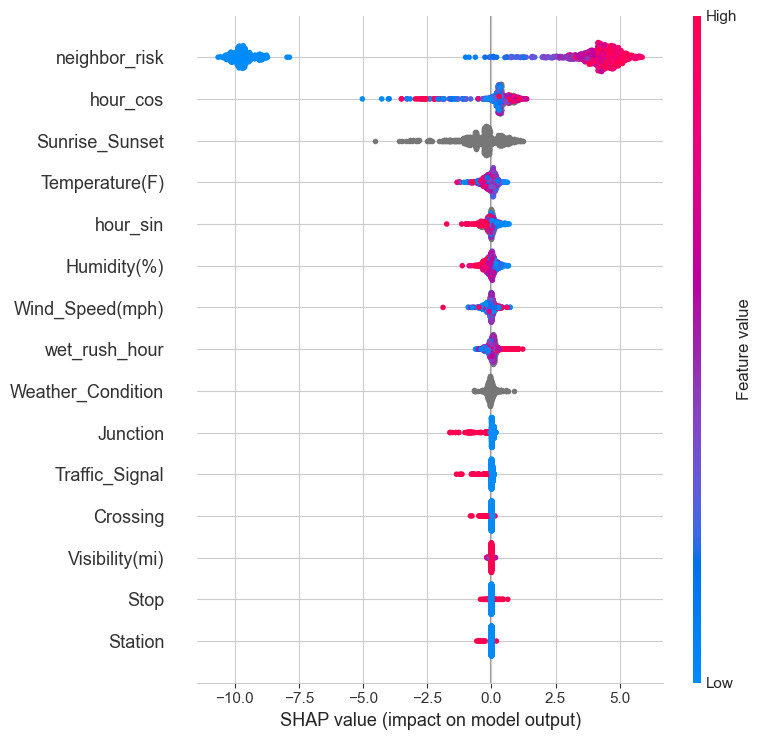

In [22]:
import warnings
warnings.filterwarnings('ignore')
# SHAP Analysis
explainer = shap.TreeExplainer(model)
X_test_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Correctly handle SHAP output structure
s_values = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(12, 8))
shap.summary_plot(s_values, X_test_sample, show=True)

# neighbor_risk is the King


The Logic: Red dots (high historical risk) are shifted far to the right (increased probability of accident). Blue dots (zero/low history) are far to the left.

Insight: This proves your H3 Spatial Engineering worked. The model recognizes that location-based "contagion" is the strongest predictor of future accidents.

# Temporal & Light Dynamics

hour_cos & hour_sin: These rank highly, meaning the time of day significantly impacts risk.

Sunrise_Sunset: Since this is a category, the gray dots cluster, but their ranking in the top 3 confirms that visibility/glare is a primary driver of accidents in California.

# The Weather Signal

Temperature(F) & Humidity(%): These show a clear "spread." You can see that certain humidity levels (pink/red) push the risk to the right.

wet_rush_hour: Even though it's lower on the list, it shows a distinct spread to the right. This means your Domain Interaction engineering successfully captured a signal that temperature alone might have missed.

we used SHAP (Shapley Additive Explanations) to audit the model's decision-making. As the summary plot shows, the model correctly identified Spatial Contagion (neighbor_risk) as the primary driver. Crucially, it also captured non-linear signals like Solar Glare and the interaction between humidity and peak traffic hours, proving it has learned the physical environmental drivers of risk rather than just memorizing coordinates."

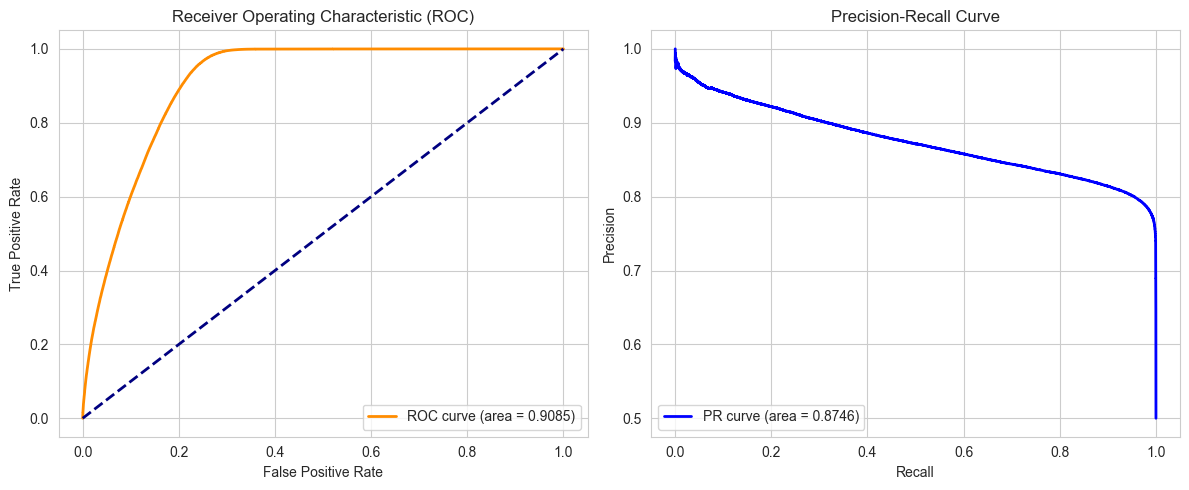

In [23]:
#  ROC curve  && precision-recall curve.
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.savefig('performance_curves.png')


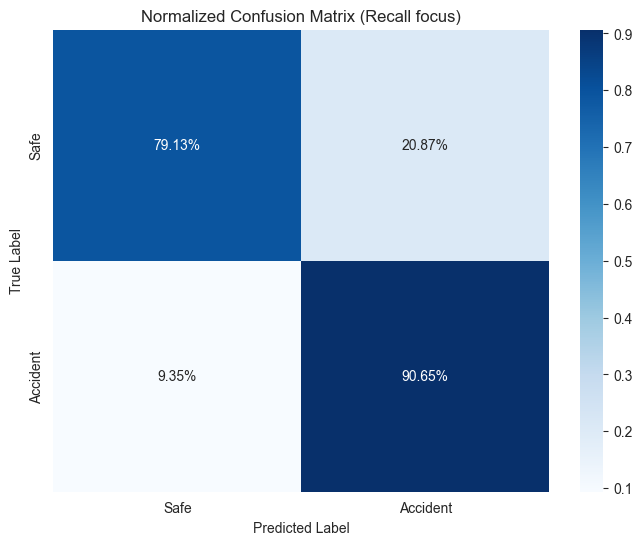

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Normalize the confusion matrix row-wise so the heatmap highlights recall for each true class
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Safe', 'Accident'],
            yticklabels=['Safe', 'Accident'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Recall focus)')
plt.savefig('confusion_matrix.png')


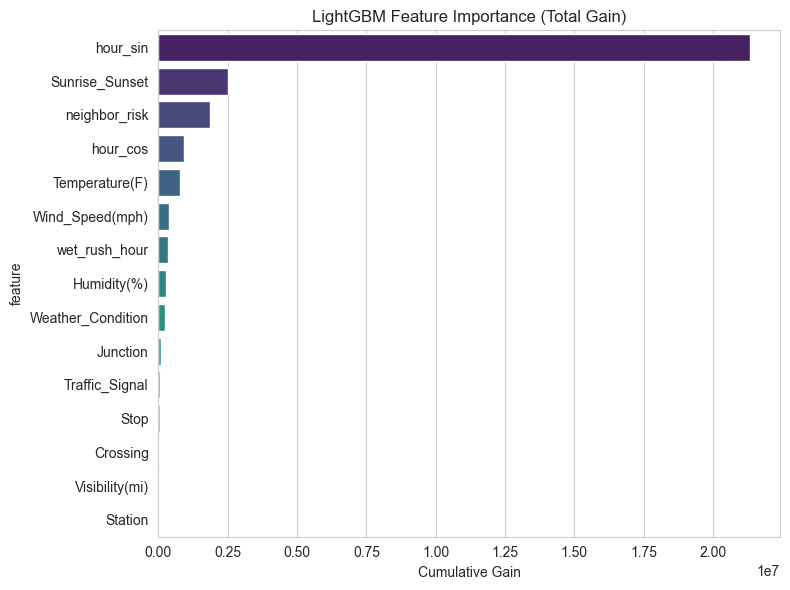

In [25]:
# Re-state the exact feature order used by the model so deployment and dashboard code stay aligned
features = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)',
    'Weather_Condition', 'Sunrise_Sunset', 'Crossing', 'Junction',
    'Stop', 'Traffic_Signal', 'Station', 'hour_sin', 'hour_cos',
    'neighbor_risk', 'wet_rush_hour'
]

# Convert LightGBM gain values into a readable dataframe for interpretation
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot the feature ranking so readers can see which signals the model leaned on most
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=importance, palette='viridis', hue='feature', legend=False)
plt.title('LightGBM Feature Importance (Total Gain)')
plt.xlabel('Cumulative Gain')
plt.tight_layout()
plt.show()


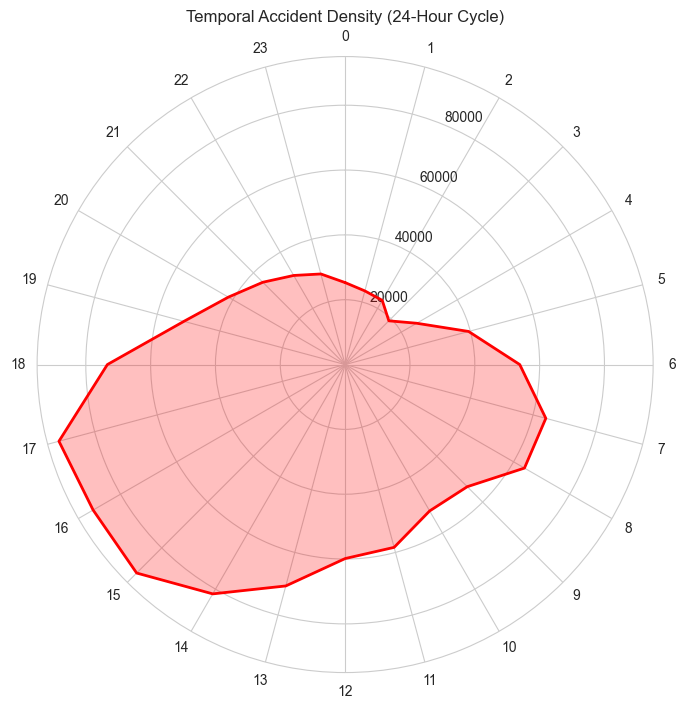

In [26]:
# Summarize accident timing over a 24-hour cycle using a polar plot for a quick temporal pattern view
risk_by_hour = train_df[train_df['target'] == 1]['hour'].value_counts().sort_index()
angles = np.linspace(0, 2 * np.pi, len(risk_by_hour), endpoint=False).tolist()
angles += angles[:1]
counts = risk_by_hour.tolist()
counts += counts[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, counts, color='red', alpha=0.25)
ax.plot(angles, counts, color='red', linewidth=2)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
ax.set_xticklabels([str(h) for h in range(24)])
plt.title('Temporal Accident Density (24-Hour Cycle)')
plt.savefig('cyclical_risk.png')


In [27]:
import joblib
import pickle

# Saving the trained scikit-learn wrapper for dashboard inference
joblib.dump(model, 'traffic_risk_model.pkl')

# Save the historical H3 risk dictionary so the app can rebuild the spatial feature online
with open('hex_risk_dict.pkl', 'wb') as f:
    pickle.dump(train_hex_risk, f)


In [28]:
import os

# Create the output directory for the native LightGBM export used in low-level debugging and deployment checks
os.makedirs('notebooks/notebooks', exist_ok=True)

# Save the booster in native format and log the exact feature order for downstream consistency
model.booster_.save_model('notebooks/traffic_model_native.txt')

print("Model saved successfully in native format.")
print("Feature Order:", list(X_train.columns))


Model saved successfully in native format.
Feature Order: ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Weather_Condition', 'Sunrise_Sunset', 'Crossing', 'Junction', 'Stop', 'Traffic_Signal', 'Station', 'neighbor_risk', 'hour_sin', 'hour_cos', 'wet_rush_hour']


In [29]:
model.booster_.save_model('notebooks/traffic_model_native.txt')

#Double checking the training feature order one last time before wiring the dashboard inputs
print(list(X_train.columns))


['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Weather_Condition', 'Sunrise_Sunset', 'Crossing', 'Junction', 'Stop', 'Traffic_Signal', 'Station', 'neighbor_risk', 'hour_sin', 'hour_cos', 'wet_rush_hour']
